In [21]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate
from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
import matplotlib.pyplot as plt
import matplotlib.ticker as tck  # Import the ticker module
import seaborn as sns



In [22]:

top20_kraken = [
    "BTC",  # 1 Bitcoin
    "ETH",  # 2 Ethereum
    "XRP",  # 3 XRP
    "BNB",  # 4 BNB
    "SOL",  # 5 Solana
    "TRX",  # 6 TRON
    "DOGE",  # 7 Dogecoin
    "ADA",  # 8 Cardano
    # "HYPE",  # 9 Hyperliquid
    "LINK",  # 10 Chainlink
    "BCH",  # 11 Bitcoin Cash
    "XLM",  # 12 Stellar
    "SUI",  # 13 Sui
    "HBAR",  # 14 Hedera
    "AVAX",  # 15 Avalanche
    "ZEC",  # 16 Zcash
    "LTC",  # 17 Litecoin
    "XMR",  # 18 Monero
    "SHIB",  # 19 Shiba Inu
    "TON",  # 20 Toncoin
    "CRO",  # 21 Crypto.com
    "DOT",  # 22 Polkadot
    "MNT",  # 23 Mantle
    "TAO",  # 24 Bittensor
    "UNI",  # 25 Uniswap
]

In [23]:
# Ticker

symbols = ["BTC"]
interval = "4h"

# Time Range

end = pd.to_datetime("2025-09-30").tz_localize('UTC')
start = end - pd.Timedelta(days=30 * 12)
# start = pd.to_datetime("2023-01-01").tz_localize('UTC')
# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3  #atr multiplier for chandelier exit
adx_threshold = 25  #trend strength
ce_high_length = 22  # look back length

# Fees
maker_fee = 0.0025
taker_fee = 0.004
transaction_fee = (maker_fee + taker_fee) / 2

# portfolio
# init_cash = 1000

#
k = KrakenHistoricalData()
s = Signals()
k.use_remote("https://garygigabytes.com/kraken/parquet")  # no trailing slash
df_multi = k.get_ohlcv_df_remote(symbols, interval=interval)
# df_multi = k.get_ohlcv_df(symbols, interval=interval)

print(df_multi.head())

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.head())

                                    BTC                              \
                                   open          high           low   
2023-01-01 00:00:00+00:00  16528.699219  16530.000000  16505.199219   
2023-01-01 04:00:00+00:00  16519.300781  16542.400391  16506.900391   
2023-01-01 08:00:00+00:00  16512.400391  16538.400391  16490.000000   
2023-01-01 12:00:00+00:00  16500.199219  16550.000000  16497.699219   
2023-01-01 16:00:00+00:00  16550.000000  16573.099609  16531.199219   

                                                                         
                                  close        volume trades base quote  
2023-01-01 00:00:00+00:00  16519.300781  2.636628e+10    803  BTC   USD  
2023-01-01 04:00:00+00:00  16510.699219  1.122105e+11   2919  BTC   USD  
2023-01-01 08:00:00+00:00  16500.199219  1.014384e+11   2536  BTC   USD  
2023-01-01 12:00:00+00:00  16549.900391  2.684441e+10   2002  BTC   USD  
2023-01-01 16:00:00+00:00  16553.699219  3.952236e+10   24

In [24]:
# Calculate indicators
signals = s.calc_signals(df.copy())

print(f"\nSignals:")
print(signals.info())
print(signals.head())

print("woot")


                                   open          high           low  \
2024-10-05 00:00:00+00:00  62081.000000  62192.101562  61700.000000   
2024-10-05 04:00:00+00:00  61892.101562  62244.000000  61819.699219   
2024-10-05 08:00:00+00:00  62115.699219  62268.500000  62094.601562   
2024-10-05 12:00:00+00:00  62195.398438  62328.300781  62114.300781   
2024-10-05 16:00:00+00:00  62159.898438  62159.898438  61792.101562   

                                  close        volume  trades base quote  \
2024-10-05 00:00:00+00:00  61892.101562  5.927125e+11    2368  BTC   USD   
2024-10-05 04:00:00+00:00  62115.601562  3.209886e+11    1810  BTC   USD   
2024-10-05 08:00:00+00:00  62195.398438  2.331592e+11    1641  BTC   USD   
2024-10-05 12:00:00+00:00  62159.898438  1.841867e+11    2179  BTC   USD   
2024-10-05 16:00:00+00:00  61819.898438  5.120985e+11    2801  BTC   USD   

                                    sar  sar_s  ...  adx_s  adx_bullish  \
2024-10-05 00:00:00+00:00           NaN  

In [25]:
def position_time_pairs(filtered_entry: pd.Series, filtered_exit: pd.Series):
    # 2) Pair entries with the next exit after each entry
    pairs = []
    j = 0
    for et in entry_times:
        while j < len(exit_times) and exit_times[j] <= et:
            j += 1
        if j < len(exit_times):
            pairs.append((et, exit_times[j]))
            j += 1
    return pairs


def backtest_from_pairs(pairs: list, exits_price: pd.Series, entries_price: pd.Series, transaction_fee: float):
    profit = pd.Series(0.0, index=filtered_entry.index)
    profit_pct = profit.copy()
    for pair in pairs:
        exit_price = exits_price.loc[pair[1]]
        entry_price = entries_price.loc[pair[0]]
        profit.loc[pair[1]] = exit_price - entry_price - (transaction_fee * (exit_price + entry_price))
        profit_pct.loc[pair[1]] = profit.loc[pair[1]] / entry_price

    profit_cum = profit.cumsum()
    profit[profit == 0.0] = np.nan
    profit_pct[profit_pct == 0.0] = np.nan
    profit_df = pd.concat([entries_price, exits_price, profit, profit_cum, profit_pct], axis=1)
    profit_df.columns = ['Entry_Price', 'Exit_Price', 'Profit', 'Cumulative_Profit', 'Profit_Pct']

    return profit_df


def calc_wins_losses(profit: pd.Series):
    wins = (profit > 0).sum()
    loss = (profit < 0).sum()
    return wins, loss

filtered_entry = signals['filtered_entry']
filtered_exit = signals['filtered_exit']

# Backtest
entry_times = list(filtered_entry[filtered_entry].index)
exit_times = list(filtered_exit[filtered_exit].index)
pairs = position_time_pairs(filtered_entry, filtered_exit)

# Calc profits
close = signals['close']
exits_price = signals['ce_l'].shift(-1).ffill() * filtered_exit
entries_price = close * filtered_entry
profit_df = backtest_from_pairs(pairs, exits_price, entries_price, transaction_fee)

wins, loss = calc_wins_losses(profit_df['Profit'])

trading_days = (end - start).days


def sharpe_ratio(profit: pd.Series, interval: str):
    trading_map = {'4h': 6 * 365, '1h': 24 * 365, '1d': 365}
    trading_periods = trading_map.get(interval)
    return profit.mean() / profit.std() * np.sqrt(trading_periods)


def sortino_ratio(profit: pd.Series, interval: str):
    trading_map = {'4h': 6 * 365, '1h': 24 * 365, '1d': 365}
    trading_periods = trading_map.get(interval)
    return profit.mean() / profit[profit < 0].std() * np.sqrt(trading_periods)


stats = profit_df['Profit'].describe()
stats_pct = profit_df['Profit_Pct'].describe()
sharpe = sharpe_ratio(profit_df['Profit'], interval)
sortino = sortino_ratio(profit_df['Profit'], interval)
win_rate = wins / (wins + loss)
print(f"\nPerformance  Stats:")
print(f"Trading Days: {trading_days}")
print(f"Average Return: {stats['mean']:,.2f}")
print(f"Std.Dev Return: {stats['std']:,.2f}")
print(f"Average Return %: {stats_pct['mean'] * 100:,.2f}")
print(f"Std.Dev Return %: {stats_pct['std'] * 100:,.2f}")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Sortino Ratio: {sortino:,.2f}")
print(f"Total Profit: {profit_df['Cumulative_Profit'].iloc[-1]:,.2f}")
print(f"Wins: {wins}")
print(f"Losses: {loss}")
print(f"Win Rate: {win_rate:.2%}")

# print(f"\nLast 200 profit_df:")
# print(tabulate(profit_df.tail(200), headers='keys',
#                tablefmt='github'))
# With DMP >DMN  sharpe Ratio 6.29, 2 years, BTC
# without DMP> DMN Sharpe Ratio 5.41, 2 years, BTC
# with DMP > DMN Sharpe Ratio 2.08, .5 years, BTC
# without DMP> DMN Sharpe Ratio .29, .5 years, BTC


Performance  Stats:
Trading Days: 360
Average Return: 1,034.43
Std.Dev Return: 5,835.36
Average Return %: 1.65
Std.Dev Return %: 7.35
Sharpe Ratio: 8.30
Sortino Ratio: 39.65
Total Profit: 26,895.16
Wins: 11
Losses: 15
Win Rate: 42.31%


In [26]:
##  Boolean where in position
y1_arr = signals['close'].values
in_position = pd.Series(pd.NA, index=filtered_entry.index, dtype="boolean")
in_position[filtered_entry] = filtered_entry[filtered_entry]
in_position[filtered_exit] = ~filtered_exit[filtered_exit]
in_position.ffill(inplace=True)
y2 = pd.Series(np.nan, index=filtered_entry.index, dtype="float64")
y2[filtered_entry] = signals['close'][filtered_entry]
y2.ffill(inplace=True)
y2.bfill(inplace=True)
y2_arr = y2.values
in_p = in_position.fillna(False)
in_p_arr = in_p.values
mask_gt = (y1_arr > y2_arr) & in_p_arr
mask_le = (~mask_gt) & in_p_arr
# fill_between = dict(y1=y1_arr, y2=y2_arr, where=in_p_arr, facecolor='green', alpha=0.3)

# 2) Build two fill regions
fill_green = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_gt,
    facecolor='green',
    alpha=0.5
)

fill_red = dict(
    y1=y1_arr,
    y2=y2_arr,
    where=mask_le,
    facecolor='red',
    alpha=0.5
)

# 3) Pass as a list to mplfinance.plot
fill_between = [fill_green, fill_red]

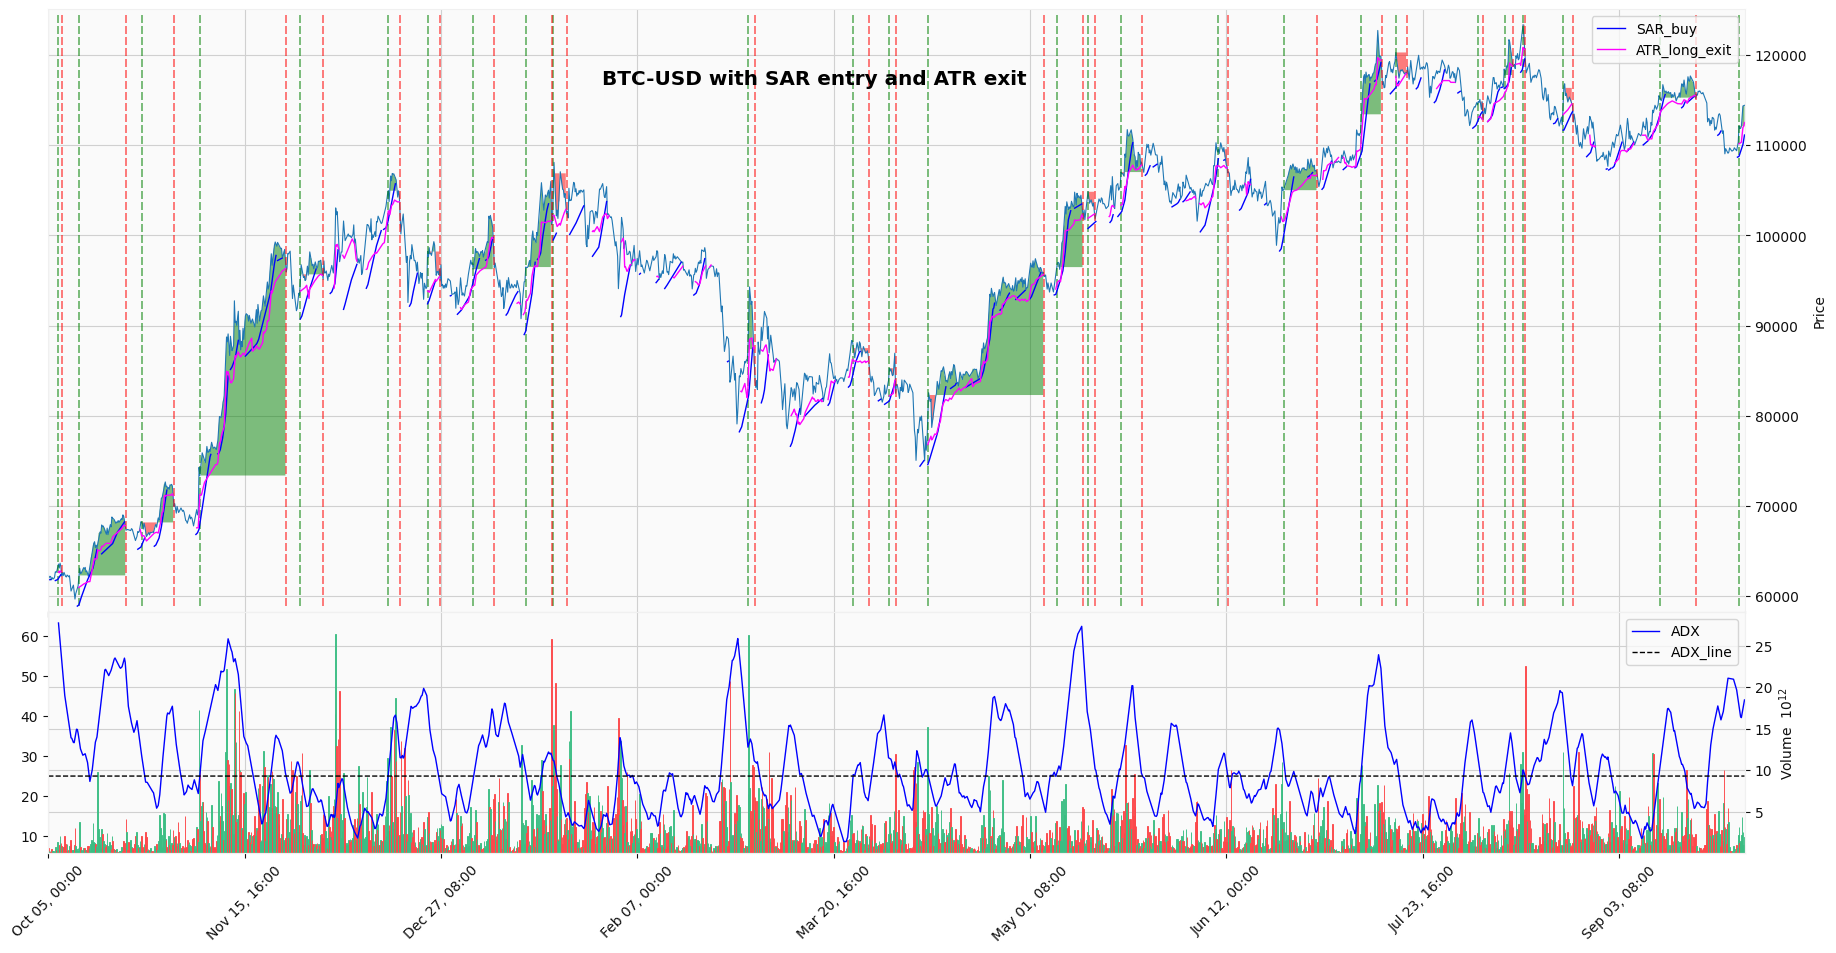

In [27]:
# Combine and color differently
vline_dates = list(filtered_entry[filtered_entry].index) + list(filtered_exit[filtered_exit].index)
vline_colors = (['g'] * filtered_entry.sum()) + (['r'] * filtered_exit.sum())
adx_line = pd.Series(adx_threshold, index=df.index)
zero_line = pd.Series(0.0, index=df.index)
addplots = [
    mpf.make_addplot(signals['sar'], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(signals['ce_l'], type='line', color='magenta', width=1.0, label='ATR_long_exit',
                     secondary_y=False),
    # mpf.make_addplot(signals['ce_sh'], type='line', width=1.0, label='ATR_short_exit',
    #                  secondary_y=False),
    mpf.make_addplot(signals['adx'], type='line', color='blue', width=1.0, label='ADX', panel=1),
    # mpf.make_addplot(signals['adx_dmp'], type='line', linestyle='--', width=1.0, label='dmp', panel=1),
    # mpf.make_addplot(signals['adx_dmn'], type='line', linestyle='--', width=1.0, label='dmn', panel=1),
    mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),
    # mpf.make_addplot(profit_cum, type='line', width=1.0, label='Profit', panel=2),
    # mpf.make_addplot(zero_line, type='line', color="black", linestyle='--', width=1.0, label='Zero_line', panel=2,
    #                  secondary_y=False),
    # mpf.make_addplot(profit, type='scatter', panel=3),

]

# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=True,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.5,
        alpha=0.5,
        linestyle='dashed',
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title=f"{symbols[0]}-USD with SAR entry and ATR exit",
    # xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
    fill_between=fill_between,

)


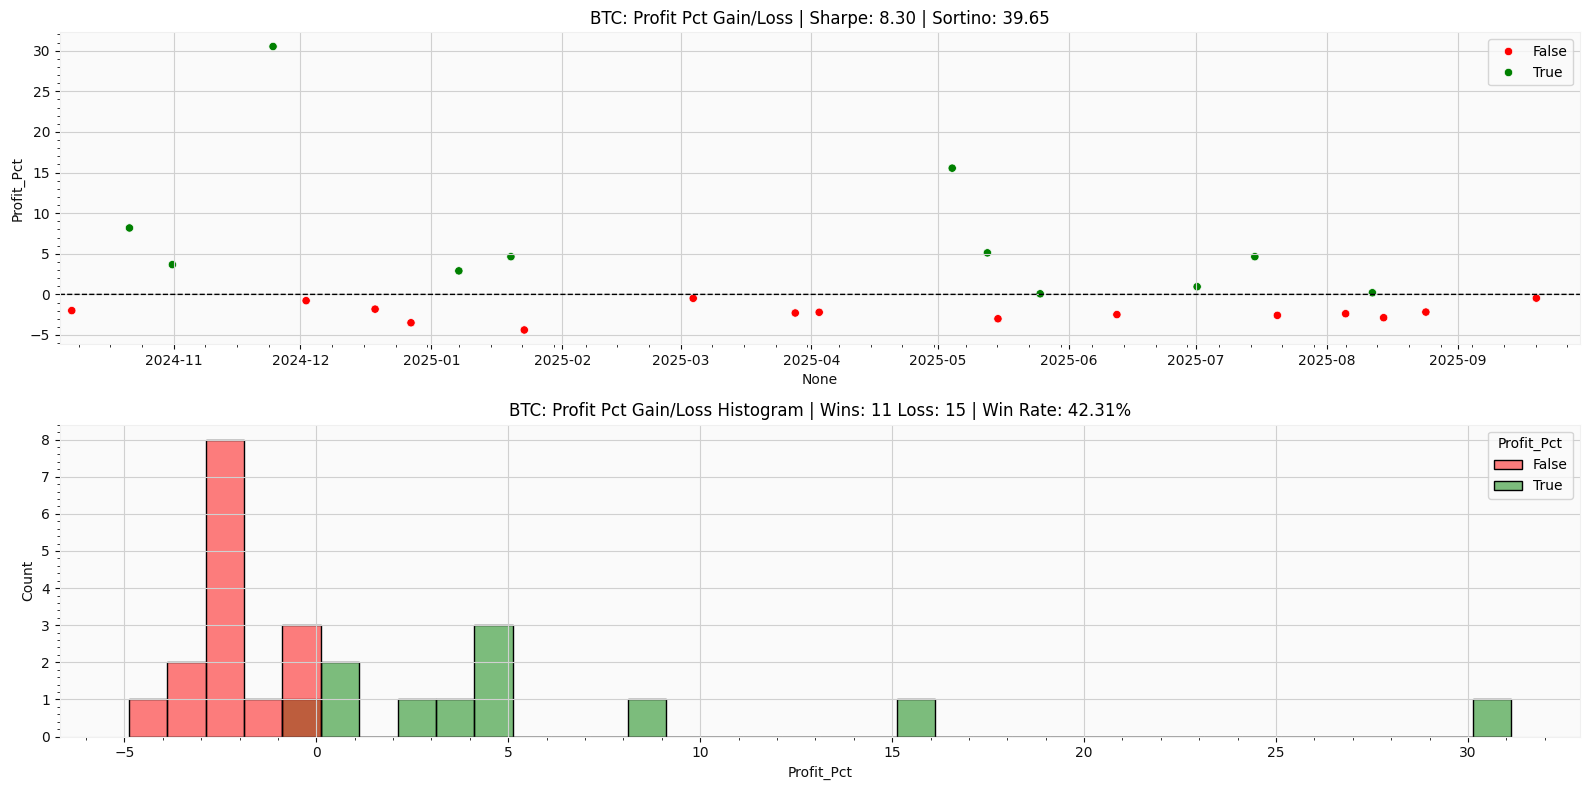

In [28]:


fig, axes = plt.subplots(2, 1, figsize=(16, 8))  # wider figure

sns.scatterplot(data=profit_df, x=profit_df.index, y=profit_df['Profit_Pct'] * 100, hue=profit_df['Profit_Pct'] > 0,
                palette={True: 'green', False: 'red'}, ax=axes[0])
sns.lineplot(zero_line, linestyle='--', color="black", linewidth=1.0, ax=axes[0])
axes[0].set_title(f"{symbols[0]}: Profit Pct Gain/Loss | Sharpe: {sharpe:.2f} | Sortino: {sortino:.2f}")
axes[0].minorticks_on()

axes[0].set_xlim(start, end)

# fig3 = plt.figure(figsize=(16, 4))  # wider figure
sns.histplot(profit_df,
             x=profit_df['Profit_Pct'] * 100,
             hue=profit_df['Profit_Pct'] > 0,
             discrete=True,
             palette={True: 'green', False: 'red'},
             ax=axes[1]
             )
axes[1].set_title(
    f"{symbols[0]}: Profit Pct Gain/Loss Histogram | Wins: {wins} Loss: {loss} | Win Rate: {win_rate:.2%}")
axes[1].minorticks_on()
plt.tight_layout()
plt.show()